<a href="https://colab.research.google.com/github/sadgee/AirBnB-Data-Analysis/blob/main/Customer_Data_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Customer Data Analysis with  KMeans Cluster

This is a RFM Analysis
1. Recency - when was recent purchase?
2. Frequency - How many times they purchased?
3. Monetary Value- what is the sum total of the amount spent?

# **Imports**

In [ ]:
import openpyxl #used for reading and writing the excel file
import pandas as pd #used for manipulation and analysis
import matplotlib.pyplot as plt #basic plotting
import seaborn as sns #for advanced statistical data visualization (built on top of matplotlib)
from sklearn.cluster import KMeans # Import KMeans algorithm for clustering from scikit-learn
from sklearn.metrics import silhouette_score #Import silhouette_score to evaluate the quality of clustering
from sklearn.preprocessing import StandardScaler

#setting to make number easier to read on display
pd.options.display.float_format ='{:20.2f}'.format

# show all columns on output
pd.set_option('display.max_columns',999)



The silhouette score for a point is defined as:

𝑠
=
𝑏
−
𝑎
/
max
⁡
(
𝑎
,
𝑏
)


Where:

a = average distance from the point to other points in the same cluster (intra-cluster distance)

b = average distance from the point to points in the nearest different cluster (nearest-cluster distance)



# **Data Exploration**

In [ ]:
# Load the first sheet of the Excel file "online_retail_II.xlsx" into a DataFrame named df
# Display the first 5 rows to preview the dataset
df = pd.read_excel("online_retail_II.xlsx", sheet_name=0)
df.head(5)

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.00,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.00,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.00,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.00,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.00,United Kingdom


In [ ]:
# Display the first 5 rows of the DataFrame df
# Provides a quick look at the dataset's columns and sample data
df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.00,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.00,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.00,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.00,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.00,United Kingdom


In [ ]:
# Display summary information about the DataFrame df, including:
# - Number of entries
# - Column names and data types
# - Non-null counts per column
# - Memory usage
# Useful for getting an overview of the dataset structure and missing data
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 525461 entries, 0 to 525460
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   Invoice      525461 non-null  object        
 1   StockCode    525461 non-null  object        
 2   Description  522533 non-null  object        
 3   Quantity     525461 non-null  int64         
 4   InvoiceDate  525461 non-null  datetime64[ns]
 5   Price        525461 non-null  float64       
 6   Customer ID  417534 non-null  float64       
 7   Country      525461 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 32.1+ MB


In [ ]:
# Generate summary statistics (count, mean, std, min, max, quartiles) for all numeric columns in cleaned_df
# Helps understand data distribution and spot anomalies or missing values
df.describe()

,Quantity,InvoiceDate,Price,Customer ID
count,525461.00,525461,525461.00,417534.00
mean,10.34,2010-06-28 11:37:36.845017856,4.69,15360.65
min,-9600.00,2009-12-01 07:45:00,-53594.36,12346.00
25%,1.00,2010-03-21 12:20:00,1.25,13983.00
50%,3.00,2010-07-06 09:51:00,2.10,15311.00
75%,10.00,2010-10-15 12:45:00,4.21,16799.00
max,19152.00,2010-12-09 20:01:00,25111.09,18287.00
std,107.42,NaN,146.13,1680.81


In [ ]:
# Change the data type of 'Customer ID' column to 'object' (string) for consistent handling of IDs
df = df.astype({
    'Customer ID':'object'
})

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 525461 entries, 0 to 525460
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   Invoice      525461 non-null  object        
 1   StockCode    525461 non-null  object        
 2   Description  522533 non-null  object        
 3   Quantity     525461 non-null  int64         
 4   InvoiceDate  525461 non-null  datetime64[ns]
 5   Price        525461 non-null  float64       
 6   Customer ID  417534 non-null  object        
 7   Country      525461 non-null  object        
dtypes: datetime64[ns](1), float64(1), int64(1), object(5)
memory usage: 32.1+ MB


In [ ]:
df.describe(include ='O')#it will only give object

,Invoice,StockCode,Description,Customer ID,Country
count,525461,525461,522533,417534.00,525461
unique,28816,4632,4681,4383.00,40
top,537434,85123A,WHITE HANGING HEART T-LIGHT HOLDER,14911.00,United Kingdom
freq,675,3516,3549,5710.00,485852


In [ ]:
# Display the first 3 rows where 'Customer ID' is missing (NaN)
# Helps inspect entries with no customer identification for data cleaning or analysis
df[df['Customer ID'].isna()].head(3) #isna - identifies where the customer id is null

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
263,489464,21733,85123a mixed,-96,2009-12-01 10:52:00,0.00,NaN,United Kingdom
283,489463,71477,short,-240,2009-12-01 10:52:00,0.00,NaN,United Kingdom
284,489467,85123A,21733 mixed,-192,2009-12-01 10:53:00,0.00,NaN,United Kingdom


In [ ]:
df[df['Quantity'] < 0 ].head(3) #C in dicates cancellation

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
178,C489449,22087,PAPER BUNTING WHITE LACE,-12,2009-12-01 10:33:00,2.95,16321.00,Australia
179,C489449,85206A,CREAM FELT EASTER EGG BASKET,-6,2009-12-01 10:33:00,1.65,16321.00,Australia
180,C489449,21895,POTTING SHED SOW 'N' GROW SET,-4,2009-12-01 10:33:00,4.25,16321.00,Australia


In [ ]:
df['Invoice'] = df['Invoice'].astype("str")
df[df['Invoice'].str.match("^\\d{6}$")== True] # d represents digit here and we want exactly 6 digits $ ends the digit
# df[df['Invoice'].str.match("^\\d{6}$")== False] will show the invoice number with character or when its not 6 digit

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.00,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.00,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.00,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.00,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.00,United Kingdom
...,...,...,...,...,...,...,...,...
525456,538171,22271,FELTCRAFT DOLL ROSIE,2,2010-12-09 20:01:00,2.95,17530.00,United Kingdom
525457,538171,22750,FELTCRAFT PRINCESS LOLA DOLL,1,2010-12-09 20:01:00,3.75,17530.00,United Kingdom
525458,538171,22751,FELTCRAFT PRINCESS OLIVIA DOLL,1,2010-12-09 20:01:00,3.75,17530.00,United Kingdom
525459,538171,20970,PINK FLORAL FELTCRAFT SHOULDER BAG,2,2010-12-09 20:01:00,3.75,17530.00,United Kingdom


In [ ]:
df['Invoice'].str.replace("[0-9]","",regex=True).unique() #regex is a regular expression (sequence of character that defines a search pattern)

array(['', 'C', 'A'], dtype=object)

In [ ]:
df['Invoice'] = df['Invoice'].astype("str")
df[df['Invoice'].str.match("^[A]\d{6}$")== True] #we got invoice number thatb starts with [A]

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
179403,A506401,B,Adjust bad debt,1,2010-04-29 13:36:00,-53594.36,NaN,United Kingdom
276274,A516228,B,Adjust bad debt,1,2010-07-19 11:24:00,-44031.79,NaN,United Kingdom
403472,A528059,B,Adjust bad debt,1,2010-10-20 12:04:00,-38925.87,NaN,United Kingdom


In [ ]:
df[df['Invoice'].str.startswith("A")]

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
179403,A506401,B,Adjust bad debt,1,2010-04-29 13:36:00,-53594.36,NaN,United Kingdom
276274,A516228,B,Adjust bad debt,1,2010-07-19 11:24:00,-44031.79,NaN,United Kingdom
403472,A528059,B,Adjust bad debt,1,2010-10-20 12:04:00,-38925.87,NaN,United Kingdom


In [ ]:
# Load the first sheet of the Excel file "online_retail_II.xlsx" into a DataFrame
# Convert the 'StockCode' column to string type for consistent processing
# Filter rows where 'StockCode' consists exactly of 5 digits
df = pd.read_excel("online_retail_II.xlsx", sheet_name=0)
df['StockCode'] = df['StockCode'].astype("str")
df[df['StockCode'].str.match("^\\d{5}$") == True]

#df['StockCode'] = df['StockCode'].astype("str")
#df[df['StockCode'].str.match("^\\d{5}$") == False]


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.00,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.00,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.00,United Kingdom
5,489434,22064,PINK DOUGHNUT TRINKET POT,24,2009-12-01 07:45:00,1.65,13085.00,United Kingdom
6,489434,21871,SAVE THE PLANET MUG,24,2009-12-01 07:45:00,1.25,13085.00,United Kingdom
...,...,...,...,...,...,...,...,...
525456,538171,22271,FELTCRAFT DOLL ROSIE,2,2010-12-09 20:01:00,2.95,17530.00,United Kingdom
525457,538171,22750,FELTCRAFT PRINCESS LOLA DOLL,1,2010-12-09 20:01:00,3.75,17530.00,United Kingdom
525458,538171,22751,FELTCRAFT PRINCESS OLIVIA DOLL,1,2010-12-09 20:01:00,3.75,17530.00,United Kingdom
525459,538171,20970,PINK FLORAL FELTCRAFT SHOULDER BAG,2,2010-12-09 20:01:00,3.75,17530.00,United Kingdom


In [ ]:
# Remove all digits from each StockCode string
# Return unique resulting strings after digit removal to identify any remaining patterns or characters
df["StockCode"].str.replace("[0-9]","",regex = True).unique()

array(['', 'P', 'W', 'C', 'B', 'F', 'L', 'S', 'A', 'N', 'POST', 'E', 'J',
       'D', 'G', 'LP', 'BL', 'K', 'H', 'GR', 'M', 'DCGS', 'DOT', 'U', 'b',
       'w', 'c', 'a', 'f', 'bl', 's', 'p', 'R', 'V', 'T', 'I',
       'BANK CHARGES', 'O', 'Z', 'TEST', 'gift__', 'DCGSN', 'm', 'PADS',
       'Y', 'HC', 'e', 'd', 'ADJUST', 'DCGSSGIRL', 'GIFT', 'DCGSLBOY',
       'k', 'g', 'DCGSSBOY', 'DCGSLGIRL', 'j', 'l', 'n', 'J ', 'SP',
       'AMAZONFEE'], dtype=object)

In [ ]:
# Convert 'StockCode' to string type for pattern matching
# Find unique StockCodes that do NOT match either:
#   - Exactly 5 digits
#   - Exactly 5 digits followed by a single letter
# Returns an array of these unmatched StockCodes for review or cleaning
df['StockCode'] = df['StockCode'].astype("str")
df[(df['StockCode'].str.match("^\\d{5}$") == False) &(df['StockCode'].str.match("^\\d{5}[a-zA-Z]$") == False)]['StockCode'].unique()

array(['POST', '79323LP', '15056BL', 'D', '79323GR', 'DCGS0058',
       'DCGS0068', 'DOT', '15056bl', 'M', 'DCGS0004', 'DCGS0076', 'C2',
       'BANK CHARGES', 'DCGS0003', 'TEST001', 'gift_0001_80', 'DCGS0072',
       'gift_0001_20', 'DCGS0044', 'TEST002', 'gift_0001_10',
       'gift_0001_50', 'DCGS0066N', 'gift_0001_30', 'PADS', '72024HC',
       'ADJUST', 'gift_0001_40', 'gift_0001_60', 'gift_0001_70',
       'gift_0001_90', 'DCGSSGIRL', 'DCGS0006', 'DCGS0016', 'DCGS0027',
       'DCGS0036', 'DCGS0039', 'DCGS0060', 'DCGS0056', 'DCGS0059', 'GIFT',
       'DCGSLBOY', 'm', 'DCGS0053', 'DCGS0062', 'DCGS0037', 'DCGSSBOY',
       'DCGSLGIRL', 'S', 'DCGS0069', 'DCGS0070', 'DCGS0075', 'B',
       'DCGS0041', 'ADJUST2', '47503J ', 'C3', 'SP1002', 'AMAZONFEE'],
      dtype=object)

In [ ]:
# Filter rows in df where the 'StockCode' starts with the string "DOT"
# Uses regex '^DOT' to match StockCodes beginning with 'DOT'
df[df["StockCode"].str.contains("^DOT")]

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
2379,489597,DOT,DOTCOM POSTAGE,1,2009-12-01 14:28:00,647.19,NaN,United Kingdom
2539,489600,DOT,DOTCOM POSTAGE,1,2009-12-01 14:43:00,55.96,NaN,United Kingdom
2551,489601,DOT,DOTCOM POSTAGE,1,2009-12-01 14:44:00,68.39,NaN,United Kingdom
2571,489602,DOT,DOTCOM POSTAGE,1,2009-12-01 14:45:00,59.35,NaN,United Kingdom
2619,489603,DOT,DOTCOM POSTAGE,1,2009-12-01 14:46:00,42.39,NaN,United Kingdom
...,...,...,...,...,...,...,...,...
524272,538071,DOT,DOTCOM POSTAGE,1,2010-12-09 14:09:00,885.94,NaN,United Kingdom
524887,538148,DOT,DOTCOM POSTAGE,1,2010-12-09 16:26:00,547.32,NaN,United Kingdom
525000,538149,DOT,DOTCOM POSTAGE,1,2010-12-09 16:27:00,620.68,NaN,United Kingdom
525126,538153,DOT,DOTCOM POSTAGE,1,2010-12-09 16:31:00,822.94,NaN,United Kingdom


### **DATA CLEANING**

In [ ]:
cleaned_df = df.copy()

In [ ]:
# Convert 'StockCode' to string type for regex matching
# Create a mask to keep rows where StockCode is:
#   - Exactly 5 digits
#   - 5 digits followed by letters
#   - Exactly 'PADS'
# Filter cleaned_df to keep only rows with valid StockCodes
# Display the filtered DataFrame
cleaned_df["Invoice"] = cleaned_df["Invoice"].astype("str")

mask =(
    cleaned_df['Invoice'].str.match("^\\d{6}$") == True
)

cleaned_df = cleaned_df[mask] #follows the mask
cleaned_df

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.00,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.00,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.00,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.00,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.00,United Kingdom
...,...,...,...,...,...,...,...,...
525456,538171,22271,FELTCRAFT DOLL ROSIE,2,2010-12-09 20:01:00,2.95,17530.00,United Kingdom
525457,538171,22750,FELTCRAFT PRINCESS LOLA DOLL,1,2010-12-09 20:01:00,3.75,17530.00,United Kingdom
525458,538171,22751,FELTCRAFT PRINCESS OLIVIA DOLL,1,2010-12-09 20:01:00,3.75,17530.00,United Kingdom
525459,538171,20970,PINK FLORAL FELTCRAFT SHOULDER BAG,2,2010-12-09 20:01:00,3.75,17530.00,United Kingdom


In [ ]:
# Convert 'StockCode' to string type for pattern matching
# Create a mask to keep rows where StockCode matches one of the following patterns:
#   - Exactly 5 digits (e.g., '12345')
#   - 5 digits followed by letters (e.g., '12345AB')
#   - Exactly 'PADS'
# Filter cleaned_df to retain only rows with valid StockCodes based on these patterns
# Display the filtered DataFrame
cleaned_df['StockCode'] = cleaned_df['StockCode'].astype("str")
mask =(
    (cleaned_df['StockCode'].str.match("^\\d{5}$") ==True)
    |(cleaned_df['StockCode'].str.match("^\\d{5}[a-zA-Z]+$") ==True)
    |(cleaned_df['StockCode'].str.match("^PADS$") ==True)
)
cleaned_df = cleaned_df[mask]
cleaned_df

/tmp/ipython-input-22-1524048505.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  cleaned_df['StockCode'] = cleaned_df['StockCode'].astype("str")


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.00,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.00,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.00,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.00,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.00,United Kingdom
...,...,...,...,...,...,...,...,...
525456,538171,22271,FELTCRAFT DOLL ROSIE,2,2010-12-09 20:01:00,2.95,17530.00,United Kingdom
525457,538171,22750,FELTCRAFT PRINCESS LOLA DOLL,1,2010-12-09 20:01:00,3.75,17530.00,United Kingdom
525458,538171,22751,FELTCRAFT PRINCESS OLIVIA DOLL,1,2010-12-09 20:01:00,3.75,17530.00,United Kingdom
525459,538171,20970,PINK FLORAL FELTCRAFT SHOULDER BAG,2,2010-12-09 20:01:00,3.75,17530.00,United Kingdom


In [ ]:
# Generate summary statistics (count, mean, std, min, max, quartiles) for all numeric columns in cleaned_df
# Helps understand data distribution and spot anomalies or missing values
cleaned_df.describe()

,Quantity,InvoiceDate,Price,Customer ID
count,512796.00,512796,512796.00,406337.00
mean,11.00,2010-06-28 18:26:52.709732352,3.39,15373.63
min,-9600.00,2009-12-01 07:45:00,0.00,12346.00
25%,1.00,2010-03-21 13:27:00,1.25,14004.00
50%,3.00,2010-07-06 14:25:00,2.10,15326.00
75%,10.00,2010-10-15 14:50:00,4.21,16814.00
max,19152.00,2010-12-09 20:01:00,1157.15,18287.00
std,104.35,NaN,5.07,1677.37


In [ ]:
cleaned_df.head(3)

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.00,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.00,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.00,United Kingdom


In [ ]:
cleaned_df.dropna(subset =['Customer ID'],inplace =True) #droped the null values of customer ID (inplace- cahnges are made in the existing dataframe)

/tmp/ipython-input-25-2729825708.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  cleaned_df.dropna(subset =['Customer ID'],inplace =True) #droped the null values of customer ID (inplace- cahnges are made in the existing dataframe)


In [ ]:
cleaned_df.describe()

,Quantity,InvoiceDate,Price,Customer ID
count,406337.00,406337,406337.00,406337.00
mean,13.62,2010-07-01 10:11:06.543288320,2.99,15373.63
min,1.00,2009-12-01 07:45:00,0.00,12346.00
25%,2.00,2010-03-26 14:01:00,1.25,14004.00
50%,5.00,2010-07-09 15:48:00,1.95,15326.00
75%,12.00,2010-10-14 17:09:00,3.75,16814.00
max,19152.00,2010-12-09 20:01:00,295.00,18287.00
std,97.00,NaN,4.29,1677.37


In [ ]:
# Count the number of rows in cleaned_df where the Price is exactly zero
# Useful to check for any remaining invalid or free items in the dataset
len(cleaned_df[cleaned_df['Price'] == 0])

28

In [ ]:
# Filter out rows where the Price is less than or equal to zero
# Keeps only valid sales records with positive prices in cleaned_df
cleaned_df = cleaned_df[cleaned_df['Price'] > 0]

In [ ]:
cleaned_df.describe()

,Quantity,InvoiceDate,Price,Customer ID
count,406309.00,406309,406309.00,406309.00
mean,13.62,2010-07-01 10:14:25.869572352,2.99,15373.72
min,1.00,2009-12-01 07:45:00,0.00,12346.00
25%,2.00,2010-03-26 14:01:00,1.25,14006.00
50%,5.00,2010-07-09 15:48:00,1.95,15326.00
75%,12.00,2010-10-14 17:09:00,3.75,16814.00
max,19152.00,2010-12-09 20:01:00,295.00,18287.00
std,97.00,NaN,4.29,1677.33


In [ ]:
cleaned_df['Price'].min()

0.001

In [ ]:
(len(cleaned_df)/len(df))*100 #imp to evaluate how much data is lost(percent)

77.32429238325965

Dropped ~ 23% of the data set

# **Feature Engineering**

The feature we want to analyse are based on the RMF Model previously stated.

In [ ]:
# Calculate total sales amount for each line by multiplying Quantity by Price
# Store the result in a new column 'SalesLineTotal' in cleaned_df
cleaned_df["SalesLineTotal"] = cleaned_df['Quantity']*cleaned_df['Price']

/tmp/ipython-input-32-3168465375.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  cleaned_df["SalesLineTotal"] = cleaned_df['Quantity']*cleaned_df['Price']


In [ ]:
cleaned_df

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,SalesLineTotal
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.00,United Kingdom,83.40
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.00,United Kingdom,81.00
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.00,United Kingdom,81.00
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.00,United Kingdom,100.80
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.00,United Kingdom,30.00
...,...,...,...,...,...,...,...,...,...
525456,538171,22271,FELTCRAFT DOLL ROSIE,2,2010-12-09 20:01:00,2.95,17530.00,United Kingdom,5.90
525457,538171,22750,FELTCRAFT PRINCESS LOLA DOLL,1,2010-12-09 20:01:00,3.75,17530.00,United Kingdom,3.75
525458,538171,22751,FELTCRAFT PRINCESS OLIVIA DOLL,1,2010-12-09 20:01:00,3.75,17530.00,United Kingdom,3.75
525459,538171,20970,PINK FLORAL FELTCRAFT SHOULDER BAG,2,2010-12-09 20:01:00,3.75,17530.00,United Kingdom,7.50


In [ ]:
# Aggregate cleaned_df by Customer ID to create RFM summary:
# - MonetaryValue: sum of SalesLineTotal (total spend per customer)
# - Frequency: count of unique invoices (number of purchases)
# - LastInvoiceDate: most recent purchase date
# as_index=False keeps Customer ID as a column, not an index
# Display the aggregated DataFrame
aggregated_df = cleaned_df.groupby(by = "Customer ID", as_index= False).agg(
         MonetaryValue = ("SalesLineTotal","sum"),
         Frequency =("Invoice","nunique"),
         LastInvoiceDate = ("InvoiceDate","max")
       )
aggregated_df

,Customer ID,MonetaryValue,Frequency,LastInvoiceDate
0,12346.00,169.36,2,2010-06-28 13:53:00
1,12347.00,1323.32,2,2010-12-07 14:57:00
2,12348.00,221.16,1,2010-09-27 14:59:00
3,12349.00,2221.14,2,2010-10-28 08:23:00
4,12351.00,300.93,1,2010-11-29 15:23:00
...,...,...,...,...
4280,18283.00,641.77,6,2010-11-22 15:30:00
4281,18284.00,411.68,1,2010-10-04 11:33:00
4282,18285.00,377.00,1,2010-02-17 10:24:00
4283,18286.00,1246.43,2,2010-08-20 11:57:00


In [ ]:
aggregated_df['MonetaryValue'].min()

1.55

In [ ]:
aggregated_df[aggregated_df['MonetaryValue'] == 1.55]
#aggregated_df[aggregated_df['MonetaryValue'] == aggregated_df['MonetaryValue'].min()]

,Customer ID,MonetaryValue,Frequency,LastInvoiceDate
2943,16454.00,1.55,1,2010-04-07 15:54:00


In [ ]:
# Find the Customer ID of the customer with the minimum MonetaryValue in the aggregated_df
# Uses idxmin() to get the index of the lowest MonetaryValue and loc to retrieve the corresponding Customer ID

aggregated_df.loc[aggregated_df['MonetaryValue'].idxmin(),"Customer ID"]

np.float64(16454.0)

In [ ]:
# Calculate recency by finding the difference in days between the latest invoice date and each customer's last purchase date
# Adds a new 'Recency' column representing how many days ago each customer made their last purchase
# Display the first 5 rows to verify the new column

max_invoice_date = aggregated_df["LastInvoiceDate"].max() #determine the recency
aggregated_df["Recency"] = (max_invoice_date - aggregated_df["LastInvoiceDate"]).dt.days #dt.days gives tinteger value
aggregated_df.head(5)



,Customer ID,MonetaryValue,Frequency,LastInvoiceDate,Recency
0,12346.00,169.36,2,2010-06-28 13:53:00,164
1,12347.00,1323.32,2,2010-12-07 14:57:00,2
2,12348.00,221.16,1,2010-09-27 14:59:00,73
3,12349.00,2221.14,2,2010-10-28 08:23:00,42
4,12351.00,300.93,1,2010-11-29 15:23:00,10


*next step is to identify the outliers would significantly disrupt the efficacy of the Kmeans alogirthm*

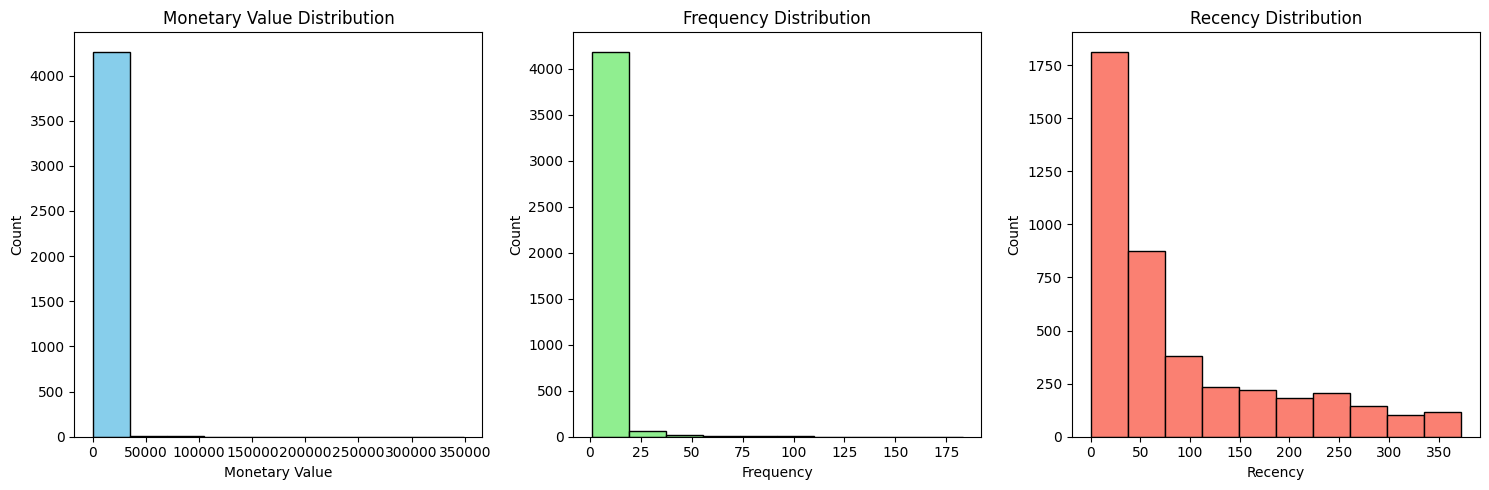

In [ ]:
# Plot histograms for MonetaryValue, Frequency, and Recency in the aggregated dataset
# Each subplot shows the frequency distribution of the respective feature with 10 bins
# Helps visualize the overall data distribution and detect skewness or concentration areas


plt.figure(figsize = (15,5))
plt.subplot(1,3,1)
plt.hist(aggregated_df['MonetaryValue'],bins = 10, color ='skyblue',edgecolor ="black")
plt.title("Monetary Value Distribution")
plt.xlabel("Monetary Value")
plt.ylabel("Count")

plt.subplot(1,3,2)
plt.hist(aggregated_df['Frequency'],bins = 10, color = 'lightgreen',edgecolor ="black")
plt.title("Frequency Distribution")
plt.xlabel("Frequency")
plt.ylabel("Count")


plt.subplot(1,3,3)
plt.hist(aggregated_df['Recency'],bins = 10, color ='salmon',edgecolor ="black")
plt.title("Recency Distribution")
plt.xlabel("Recency")
plt.ylabel("Count")

plt.tight_layout()
plt.show()


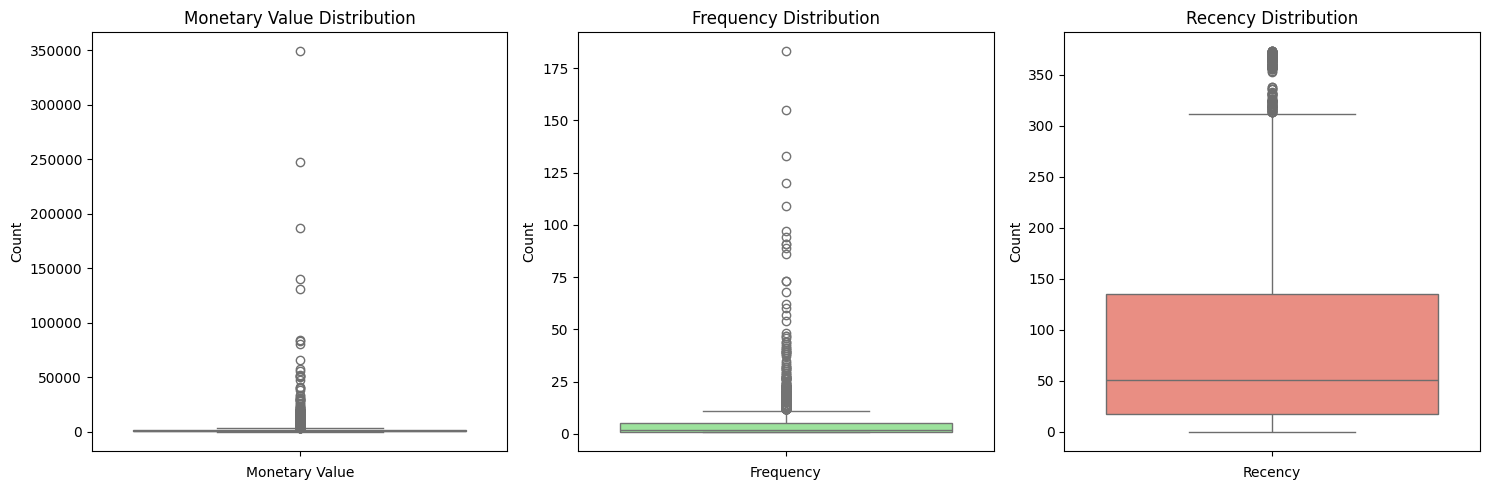

In [ ]:
# Plot boxplots for MonetaryValue, Frequency, and Recency in the full aggregated dataset
# Each plot visualizes the distribution and potential outliers for the respective RFM feature
# Helps identify spread, central tendency, and extreme values in the overall data

plt.figure(figsize=(15,5))
plt.subplot(1,3,1)
sns.boxplot(data = aggregated_df['MonetaryValue'], color ='skyblue')
plt.title("Monetary Value Distribution")
plt.xlabel("Monetary Value")
plt.ylabel("Count")

plt.subplot(1,3,2)
sns.boxplot(data = aggregated_df['Frequency'], color ='lightgreen')
plt.title("Frequency Distribution")
plt.xlabel("Frequency")
plt.ylabel("Count")


plt.subplot(1,3,3)
sns.boxplot(data = aggregated_df['Recency'], color ='salmon')
plt.title("Recency Distribution")
plt.xlabel("Recency")
plt.ylabel("Count")

plt.tight_layout()
plt.show()

#box plot represents 25 and 75 percent of data so below line it shows the 25
#read about boxplot


In [ ]:
# Calculate the first (Q1) and third (Q3) quartiles of MonetaryValue and compute the interquartile range (IQR)
# Identify outliers in MonetaryValue that lie above Q3 + 1.5*IQR or below Q1 - 1.5*IQR (extreme values)
# Create MonetaryValue_df containing these outlier customers (using .copy() to avoid SettingWithCopyWarning)
# Display descriptive statistics for the identified MonetaryValue outliers

M_Q1 = aggregated_df['MonetaryValue'].quantile(0.25)
M_Q3 = aggregated_df['MonetaryValue'].quantile(0.75)
M_IOR =M_Q3 - M_Q1
MonetaryValue_df= aggregated_df[(aggregated_df['MonetaryValue']> (M_Q3 + 1.5*M_IOR))| (aggregated_df['MonetaryValue'] < (M_Q1 - 1.5*M_IOR))].copy()
MonetaryValue_df.describe()

,Customer ID,MonetaryValue,Frequency,LastInvoiceDate,Recency
count,423.00,423.00,423.00,423,423.00
mean,15103.04,12188.10,17.17,2010-11-09 12:26:02.978723328,30.04
min,12357.00,3802.04,1.00,2009-12-10 18:03:00,0.00
25%,13622.00,4605.94,8.00,2010-11-08 13:17:30,3.00
50%,14961.00,6191.32,12.00,2010-11-26 12:19:00,13.00
75%,16692.00,10273.24,18.00,2010-12-06 10:34:30,31.00
max,18260.00,349164.35,183.00,2010-12-09 19:32:00,364.00
std,1728.66,25830.85,19.73,NaN,51.54


This shows that there are 423 outliers , which is not a small number , but when taken in context of the 500k transcations, these outliers can be eliminated

In [ ]:
# Calculate the first (Q1) and third (Q3) quartiles of Frequency and compute the interquartile range (IQR)
# Identify outliers in Frequency that lie above Q3 + 1.5*IQR or below Q1 - 1.5*IQR (unusually high or low values)
# Create Frequency_df containing these outlier customers
# Display descriptive statistics for the identified Frequency outliers

F_Q1 = aggregated_df["Frequency"].quantile(0.25)
F_Q3 = aggregated_df["Frequency"].quantile(0.75)
F_IQR = F_Q3 - F_Q1

Frequency_df = aggregated_df[(aggregated_df['Frequency'] > (F_Q3 + 1.5 * F_IQR)) | (aggregated_df['MonetaryValue'] < (F_Q1 - 1.5 * F_IQR)) ]
Frequency_df.describe()

,Customer ID,MonetaryValue,Frequency,LastInvoiceDate,Recency
count,279.00,279.00,279.00,279,279.00
mean,15352.66,14409.71,23.81,2010-11-23 11:06:20.645161216,16.09
min,12437.00,1094.39,12.00,2010-05-12 16:51:00,0.00
25%,13800.00,4331.56,13.00,2010-11-20 13:14:30,2.00
50%,15465.00,6615.77,17.00,2010-12-02 10:46:00,7.00
75%,16828.50,11692.41,23.00,2010-12-07 11:08:30,19.00
max,18260.00,349164.35,183.00,2010-12-09 19:32:00,211.00
std,1748.43,31381.74,21.93,NaN,26.59


This shows that we have 279 outliers when it comes to frequency, again, numbers we can eliminate

But there ma be an overlap between the monetary and

In [ ]:
# Select customers who are NOT outliers in either MonetaryValue or Frequency by excluding their indices
# Create a DataFrame of these non-outlier customers for further analysis
# Display summary statistics (count, mean, std, etc.) for this non-outlier subset

non_outliers_df = aggregated_df[(~aggregated_df.index.isin(MonetaryValue_df.index))&(~aggregated_df.index.isin(Frequency_df.index))]
non_outliers_df.describe()

,Customer ID,MonetaryValue,Frequency,LastInvoiceDate,Recency
count,3809.00,3809.00,3809.00,3809,3809.00
mean,15376.48,885.50,2.86,2010-09-03 11:16:46.516146176,97.08
min,12346.00,1.55,1.00,2009-12-01 10:49:00,0.00
25%,13912.00,279.91,1.00,2010-07-08 14:48:00,22.00
50%,15389.00,588.05,2.00,2010-10-12 16:25:00,58.00
75%,16854.00,1269.05,4.00,2010-11-17 13:14:00,154.00
max,18287.00,3788.21,11.00,2010-12-09 20:01:00,373.00
std,1693.20,817.67,2.24,NaN,98.11


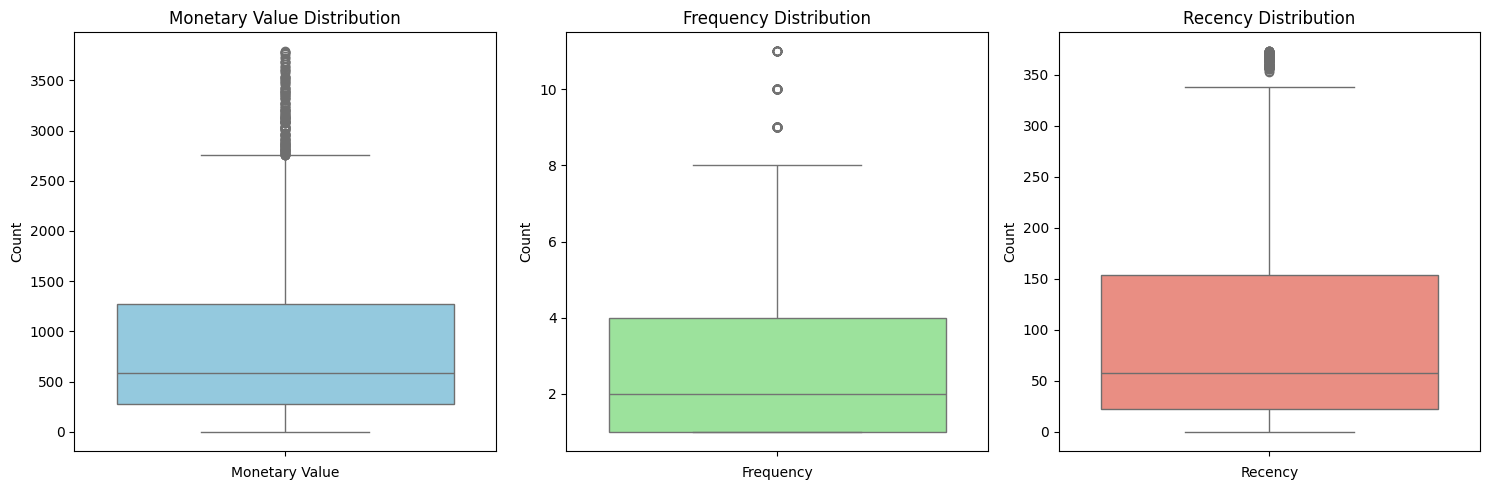

In [ ]:
# Plot boxplots for MonetaryValue, Frequency, and Recency distributions in non-outlier data
# Each subplot visualizes spread, central tendency, and potential outliers for a single RFM feature

plt.figure(figsize=(15,5))
plt.subplot(1,3,1)
sns.boxplot(data = non_outliers_df['MonetaryValue'], color ='skyblue')
plt.title("Monetary Value Distribution")
plt.xlabel("Monetary Value")
plt.ylabel("Count")

plt.subplot(1,3,2)
sns.boxplot(data = non_outliers_df['Frequency'], color ='lightgreen')
plt.title("Frequency Distribution")
plt.xlabel("Frequency")
plt.ylabel("Count")


plt.subplot(1,3,3)
sns.boxplot(data = non_outliers_df['Recency'], color ='salmon')
plt.title("Recency Distribution")
plt.xlabel("Recency")
plt.ylabel("Count")

plt.tight_layout()
plt.show()


Next we can take a 3D to display this a little better

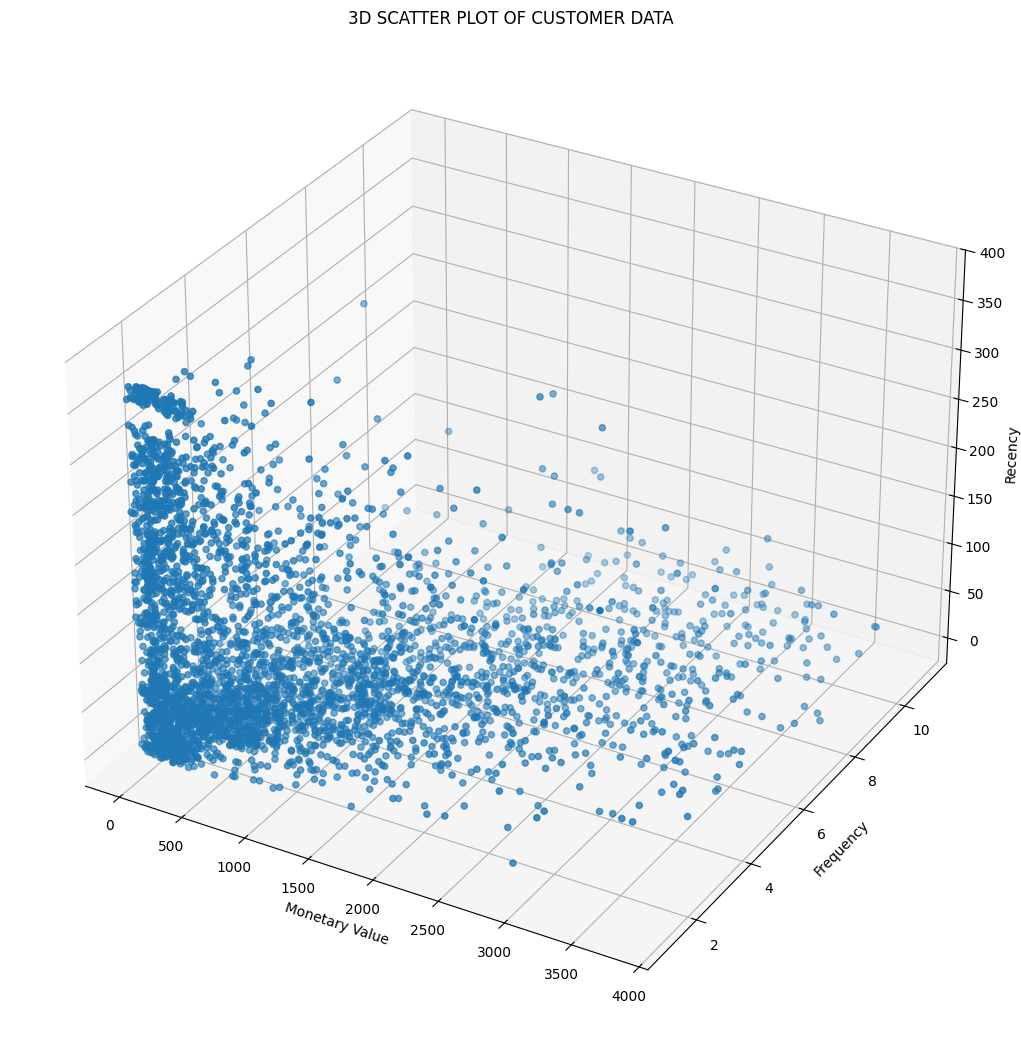

In [ ]:
# Create a 3D scatter plot of the original (unscaled) customer data using MonetaryValue, Frequency, and Recency
# Helps visualize the raw distribution of customer features before any scaling or clustering

fig = plt.figure(figsize = (13,13))
ax = fig.add_subplot(projection = '3d')
scatter = ax.scatter(non_outliers_df["MonetaryValue"], non_outliers_df["Frequency"],non_outliers_df["Recency"])

ax.set_xlabel("Monetary Value")
ax.set_ylabel("Frequency")
ax.set_zlabel("Recency")

ax.set_title("3D SCATTER PLOT OF CUSTOMER DATA")
plt.show()

Matplotlib automaticaaly scaledthe three features independently to provide a clearer picture for us. But this is ineffective as the kmeans algorithm only looks at the number and monetary value having the higher numbers would skew the algorithm to give it more impact on the analysis.
so the best thing to do is scaling which brings the number fown to [0-1], providing uniformity and avoiding biases.
However, The Z-score or standard scaling assumes that data is normally distributed. Which in our case is a fair or approximate assumption.

**How to check if the data is normal or not?**

In [ ]:
# Initialize a StandardScaler to normalize features by removing the mean and scaling to unit variance
# Apply scaling to the MonetaryValue, Frequency, and Recency columns of non_outliers_df
# Result is a numpy array with standardized feature values

scaler = StandardScaler()

scaled_data = scaler.fit_transform(non_outliers_df[["MonetaryValue","Frequency","Recency"]])

scaled_data

array([[-0.87594534, -0.38488934,  0.68214853],
       [ 0.5355144 , -0.38488934, -0.96925093],
       [-0.81258645, -0.83063076, -0.24548944],
       ...,
       [-0.62197163, -0.83063076,  2.01753946],
       [ 0.44146683, -0.38488934,  0.14187587],
       [ 1.72488781,  0.50659348, -0.81634357]])

In [ ]:
# Convert the scaled numpy array back into a pandas DataFrame
# Keep the original index and assign meaningful column names for easier analysis

scaled_data_df = pd.DataFrame(scaled_data , index = non_outliers_df.index, columns = ("MonetaryValue","Frequency","Recency"))
scaled_data_df

,MonetaryValue,Frequency,Recency
0,-0.88,-0.38,0.68
1,0.54,-0.38,-0.97
2,-0.81,-0.83,-0.25
3,1.63,-0.38,-0.56
4,-0.72,-0.83,-0.89
...,...,...,...
4280,-0.30,1.40,-0.82
4281,-0.58,-0.83,-0.32
4282,-0.62,-0.83,2.02
4283,0.44,-0.38,0.14


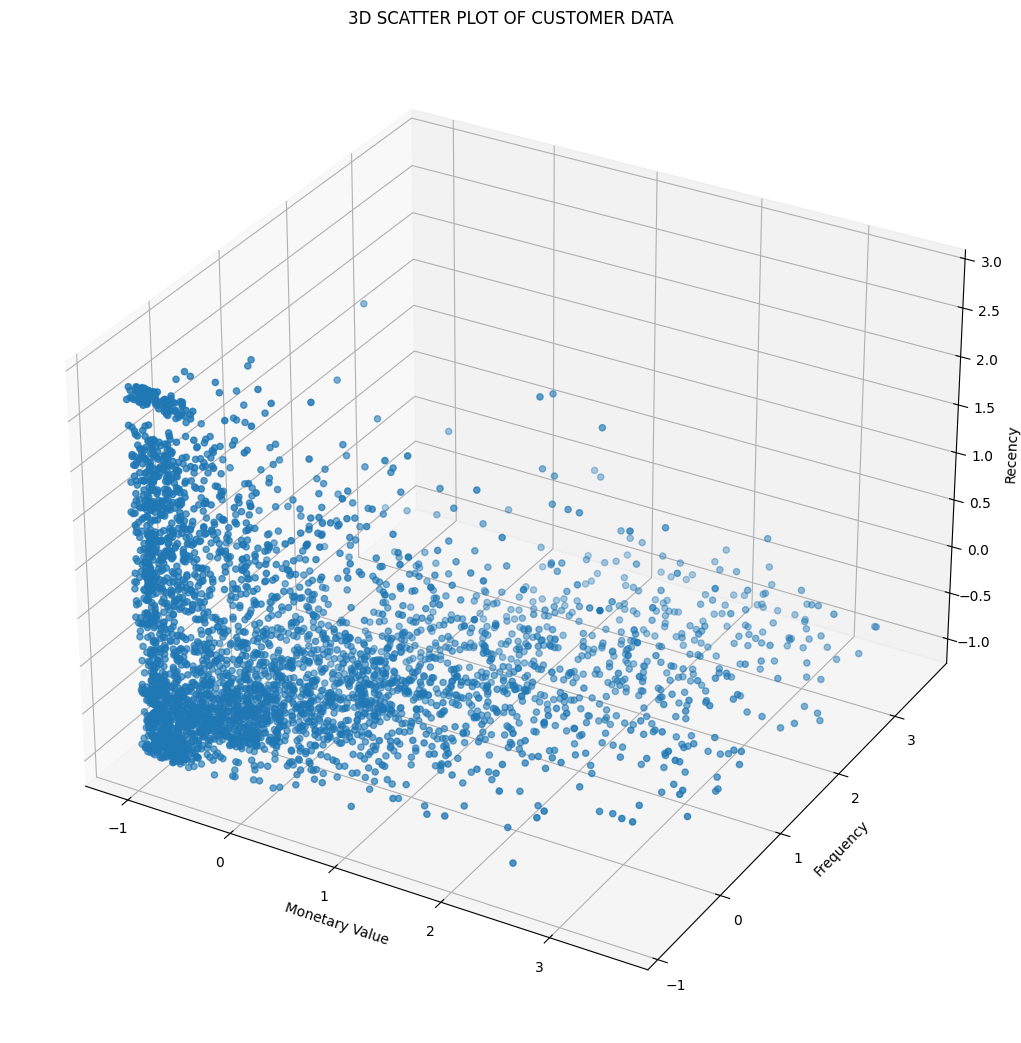

In [ ]:
# Create a 3D scatter plot of the scaled customer data using MonetaryValue, Frequency, and Recency
# Visualizes the overall data structure before clustering, without color-coding by cluster

fig = plt.figure(figsize = (13,13))
ax = fig.add_subplot(projection = '3d')
scatter = ax.scatter(scaled_data_df["MonetaryValue"], scaled_data_df["Frequency"],scaled_data_df["Recency"])

ax.set_xlabel("Monetary Value")
ax.set_ylabel("Frequency")
ax.set_zlabel("Recency")

ax.set_title("3D SCATTER PLOT OF CUSTOMER DATA")
plt.show()

So now the three columns are in comparable scaled.

Now we will do KMeans

# **KMeans Clustering**

intertia is the avg vector distance between all the points and there distance from centroid

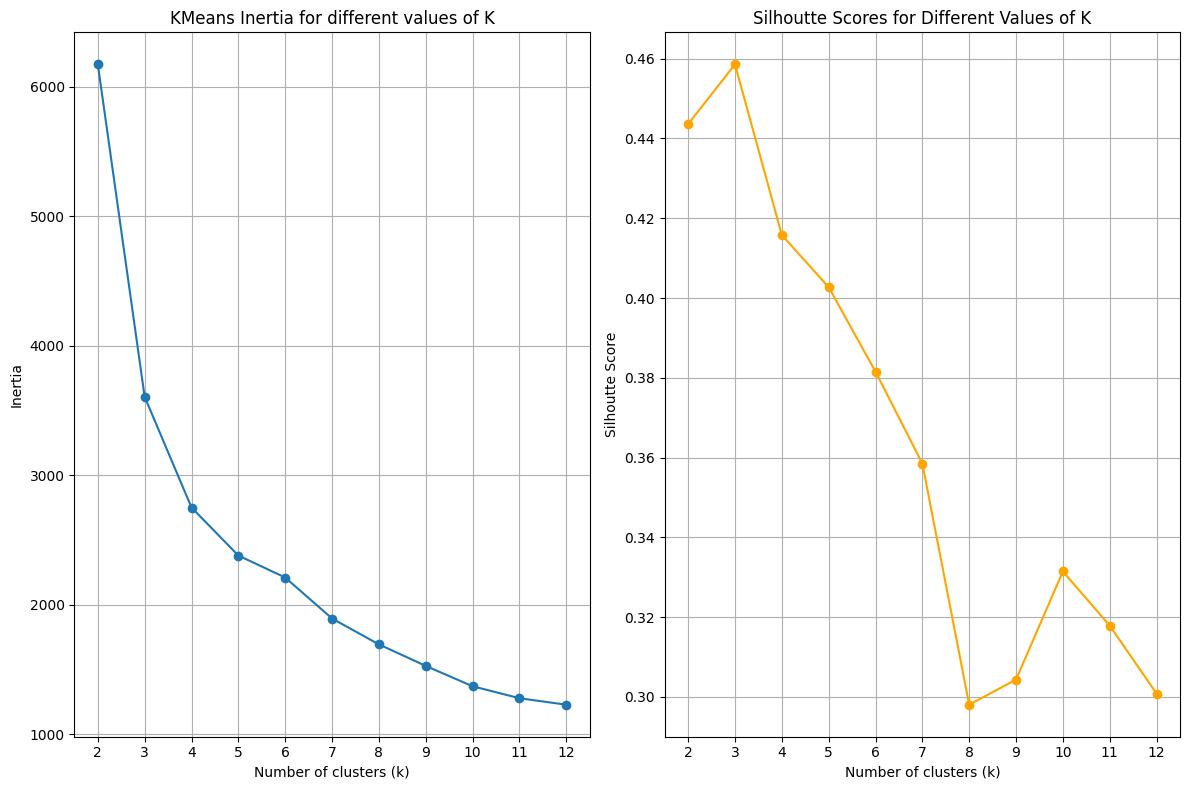

In [ ]:
# Loop through k = 2 to 12 to evaluate KMeans clustering performance
# For each k, store inertia (within-cluster variance) and silhouette score (clustering quality)
# Plot both metrics to help identify the optimal number of clusters (elbow and peak silhouette score)
max_k = 12

inertia = []
silhouette_scores = []
k_values = range(2, max_k +1)

for k in k_values:

    kmeans = KMeans(n_clusters=k, random_state=42, max_iter=1000) #random state just means you will get repeatable results, it can be any number

    cluster_labels = kmeans.fit_predict(scaled_data_df)

    sil_score = silhouette_score(scaled_data_df, cluster_labels)

    silhouette_scores.append(sil_score)

    inertia.append(kmeans.inertia_)

plt.figure(figsize=(12,8))

plt.subplot(1,2,1)
plt.plot(k_values, inertia, marker = 'o')
plt.title('KMeans Inertia for different values of K')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Inertia')
plt.xticks(k_values)
plt.grid(True) #adds a grid in the background

plt.subplot(1,2,2)
plt.plot(k_values, silhouette_scores, marker = 'o', color = 'orange')
plt.title('Silhoutte Scores for Different Values of K')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Silhoutte Score')
plt.xticks(k_values)
plt.grid(True)

plt.tight_layout()
plt.show()

In [ ]:
# Apply KMeans clustering with 4 clusters on the scaled data
# Returns cluster labels for each data point based on the fitted model

kmeans = KMeans(n_clusters = 4 , random_state =42 , max_iter = 1000)
cluster_labels = kmeans.fit_predict(scaled_data_df)
cluster_labels

array([1, 0, 2, ..., 1, 0, 0], dtype=int32)

In [ ]:
# Assign the generated KMeans cluster labels to the non_outliers_df for further analysis or visualization

non_outliers_df["Cluster"] = cluster_labels
non_outliers_df

/tmp/ipython-input-51-9260052.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  non_outliers_df["Cluster"] = cluster_labels


,Customer ID,MonetaryValue,Frequency,LastInvoiceDate,Recency,Cluster
0,12346.00,169.36,2,2010-06-28 13:53:00,164,1
1,12347.00,1323.32,2,2010-12-07 14:57:00,2,0
2,12348.00,221.16,1,2010-09-27 14:59:00,73,2
3,12349.00,2221.14,2,2010-10-28 08:23:00,42,0
4,12351.00,300.93,1,2010-11-29 15:23:00,10,2
...,...,...,...,...,...,...
4280,18283.00,641.77,6,2010-11-22 15:30:00,17,0
4281,18284.00,411.68,1,2010-10-04 11:33:00,66,2
4282,18285.00,377.00,1,2010-02-17 10:24:00,295,1
4283,18286.00,1246.43,2,2010-08-20 11:57:00,111,0


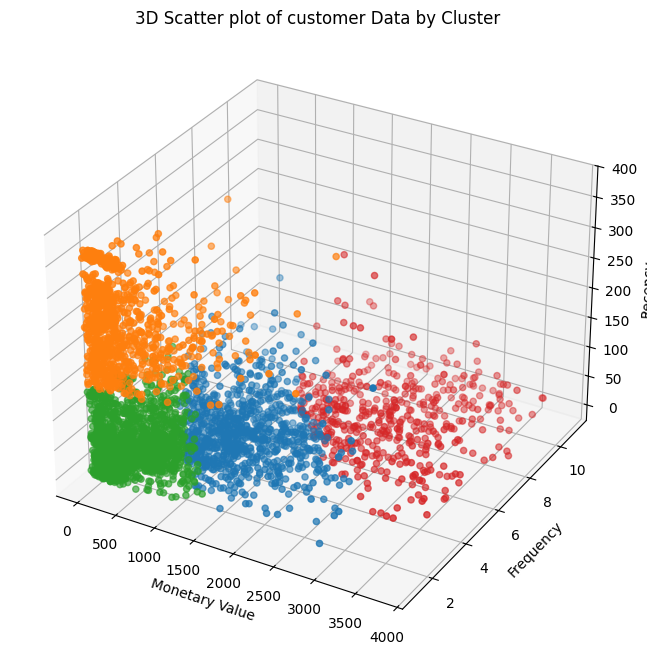

In [ ]:
# Create a 3D scatter plot to visualize customer clusters using MonetaryValue, Frequency, and Recency
# Points are colored by cluster using a custom color map for better visual separation

cluster_colors = {0: '#1f77b4',
                  1: '#ff7f0e',
                  2: '#2ca02c',
                  3: '#d62728'
                  }
colors = non_outliers_df['Cluster'].map(cluster_colors)

fig = plt.figure(figsize= (8,8))
ax = fig.add_subplot(projection = '3d')

scatter = ax.scatter(non_outliers_df['MonetaryValue'],
                     non_outliers_df['Frequency'],
                     non_outliers_df['Recency'],
                     c = colors,
                     marker ='o')

ax.set_xlabel('Monetary Value')
ax.set_ylabel('Frequency')
ax.set_zlabel('Recency')

ax.set_title('3D Scatter plot of customer Data by Cluster')
plt.show()

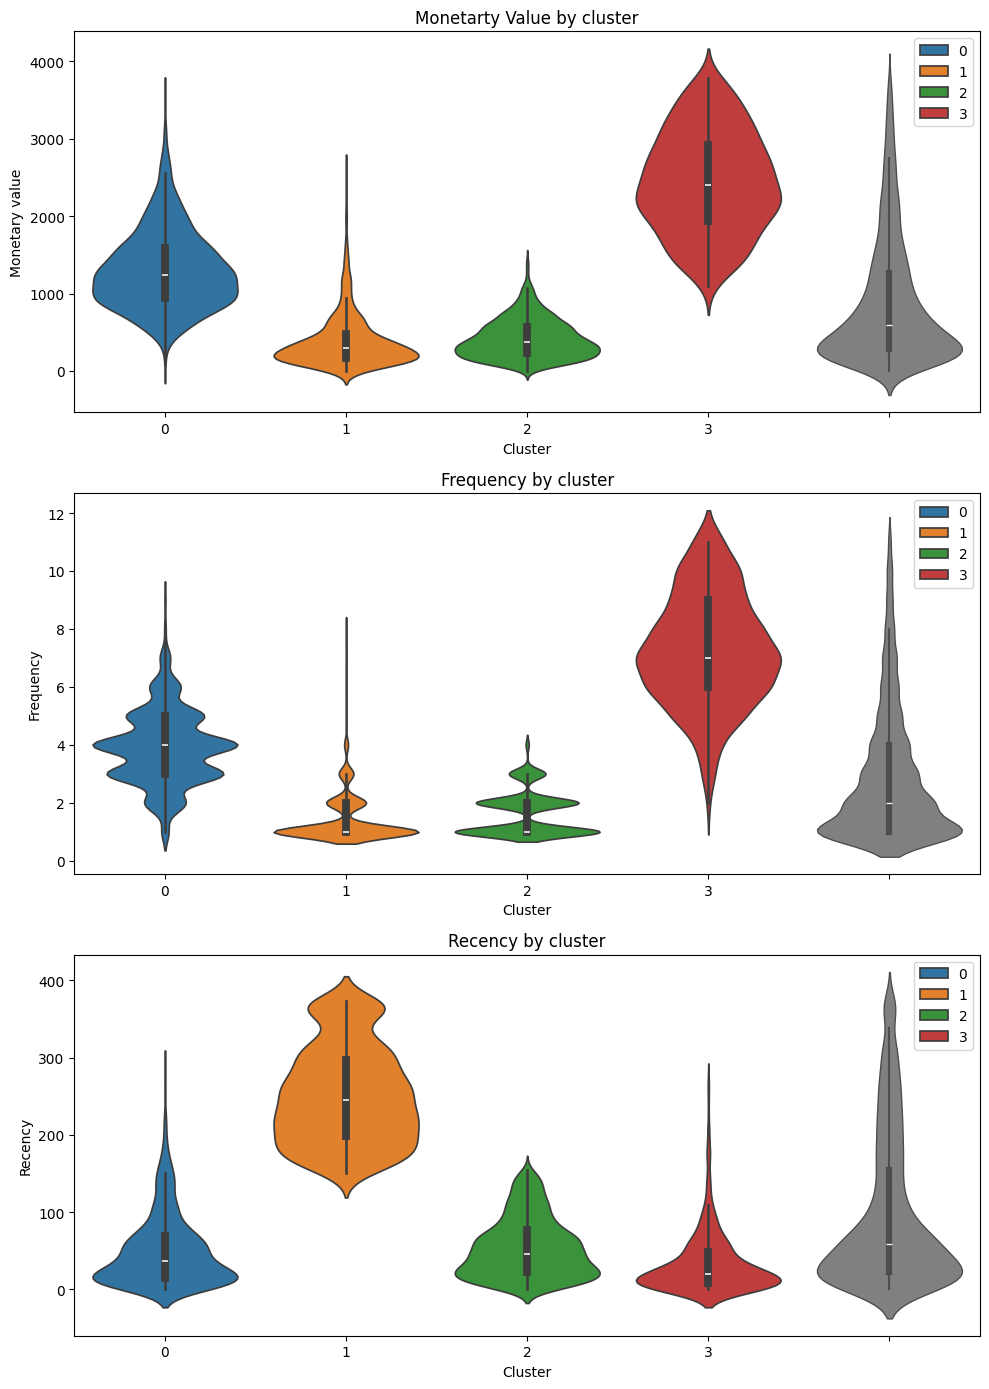

In [ ]:

# Plot violin charts for non-outlier clusters showing distributions of MonetaryValue, Frequency, and Recency
# Each subplot compares cluster-specific distributions with an overall reference in gray

plt.figure(figsize=(10,14))

plt.subplot(3,1,1)
sns.violinplot(x=non_outliers_df['Cluster'],y= non_outliers_df['MonetaryValue'], palette= cluster_colors , hue =non_outliers_df['Cluster'])
sns.violinplot(y= non_outliers_df['MonetaryValue'], color = 'gray', linewidth=1.0)
plt.title('Monetarty Value by cluster')
plt.ylabel('Monetary value')

plt.subplot(3,1,2)
sns.violinplot(x=non_outliers_df['Cluster'],y= non_outliers_df['Frequency'], palette= cluster_colors , hue =non_outliers_df['Cluster'])
sns.violinplot(y= non_outliers_df['Frequency'], color = 'gray', linewidth=1.0)
plt.title('Frequency by cluster')
plt.ylabel('Frequency')

plt.subplot(3,1,3)
sns.violinplot(x=non_outliers_df['Cluster'],y= non_outliers_df['Recency'], palette= cluster_colors , hue =non_outliers_df['Cluster'])
sns.violinplot(y= non_outliers_df['Recency'], color = 'gray', linewidth=1.0)
plt.title('Recency by cluster')
plt.ylabel('Recency')

plt.tight_layout()
plt.show()


1. cluster 0 (Blue):"Retain"
2. cluster 1 (Orange):"Re-Engage"
3. cluster 2 (Green):"Nuture"
4. cluster 3 (Red):"Reward"

In [ ]:
# Identify and label outliers: -1 for monetary-only, -2 for frequency-only, -3 for both; then combine into a single outlier DataFrame

overlap_indices = MonetaryValue_df.index.intersection(Frequency_df.index)
overlap_indices
monetary_only_outliers = MonetaryValue_df.drop(overlap_indices)
frequency_only_outliers = Frequency_df.drop(overlap_indices)
monetary_and_frequency_outliers = MonetaryValue_df.loc[overlap_indices] # Corrected line
monetary_only_outliers['Cluster'] = -1
frequency_only_outliers['Cluster'] = -2
monetary_and_frequency_outliers['Cluster'] = -3

outlier_clusters_df = pd.concat([monetary_only_outliers,frequency_only_outliers,monetary_and_frequency_outliers])
outlier_clusters_df

,Customer ID,MonetaryValue,Frequency,LastInvoiceDate,Recency,Cluster
9,12357.00,11229.99,1,2010-11-16 10:05:00,23,-1
25,12380.00,4782.84,4,2010-08-31 14:54:00,100,-1
42,12409.00,12346.62,4,2010-10-15 10:24:00,55,-1
48,12415.00,19468.84,4,2010-11-29 15:07:00,10,-1
61,12431.00,4145.52,11,2010-12-01 10:03:00,8,-1
...,...,...,...,...,...,...
4235,18223.00,7516.31,12,2010-11-17 12:20:00,22,-3
4236,18225.00,7545.14,15,2010-12-09 15:46:00,0,-3
4237,18226.00,6650.83,15,2010-11-26 15:51:00,13,-3
4241,18231.00,4791.80,23,2010-10-29 14:17:00,41,-3


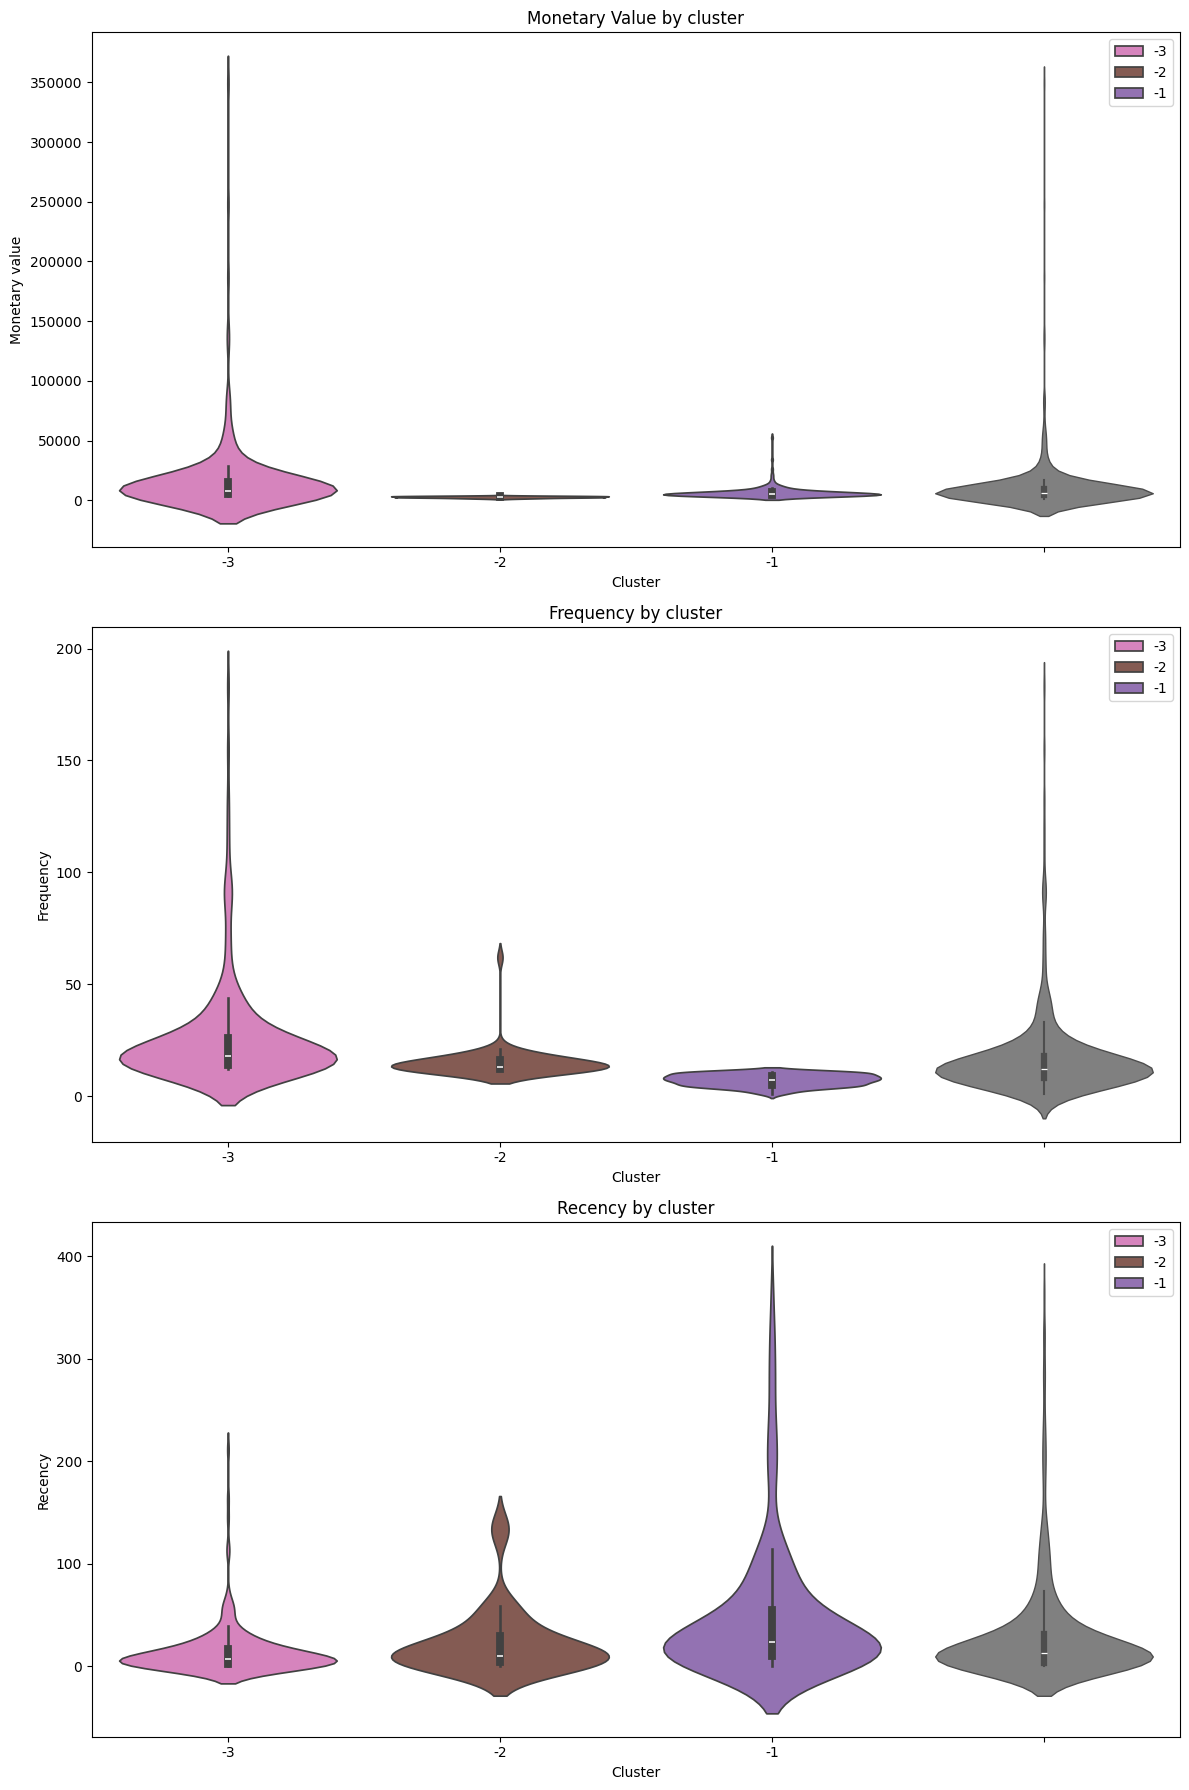

In [ ]:
# Plot violin charts to compare the distribution of MonetaryValue, Frequency, and Recency across outlier clusters (-1, -2, -3)
# Each subplot shows feature distribution by cluster with cluster-specific colors, plus a gray reference for overall distribution

cluster_colors = {-1: '#9467bd',
                  -2: '#8c564b',
                  -3: '#e377c2',

                  }
plt.figure(figsize=(12,18))

plt.subplot(3,1,1)
sns.violinplot(x=outlier_clusters_df['Cluster'],y= outlier_clusters_df['MonetaryValue'], palette= cluster_colors , hue =outlier_clusters_df['Cluster'])
sns.violinplot(y= outlier_clusters_df['MonetaryValue'], color = 'gray', linewidth=1.0)
plt.title('Monetary Value by cluster')
plt.ylabel('Monetary value')

plt.subplot(3,1,2)
sns.violinplot(x=outlier_clusters_df['Cluster'],y= outlier_clusters_df['Frequency'], palette= cluster_colors , hue =outlier_clusters_df['Cluster'])
sns.violinplot(y= outlier_clusters_df['Frequency'], color = 'gray', linewidth=1.0)
plt.title('Frequency by cluster')
plt.ylabel('Frequency')

plt.subplot(3,1,3)
sns.violinplot(x=outlier_clusters_df['Cluster'],y= outlier_clusters_df['Recency'], palette= cluster_colors , hue =outlier_clusters_df['Cluster'])
sns.violinplot(y= outlier_clusters_df['Recency'], color = 'gray', linewidth=1.0)
plt.title('Recency by cluster')
plt.ylabel('Recency')

plt.tight_layout()
plt.show()

1. cluster -1 (Monetary Outliers) PAMPER  
2. cluster -2 (Frequency Outliers) UPSELL
3. cluster -3 (Monetary & Frecuency outliers) DELIGHT


In [ ]:
cluster_labels = {
    0: "RETAIN",
    1: "RE-ENGAGE",
    2: "NURTURE",
    3: " REWARD",
    -1: "PAMPER",
    -2: "UPSELL",
    -3: "DELIGHT"
}

In [ ]:
full_clustering_df = pd.concat([non_outliers_df,outlier_clusters_df])
full_clustering_df

,Customer ID,MonetaryValue,Frequency,LastInvoiceDate,Recency,Cluster
0,12346.00,169.36,2,2010-06-28 13:53:00,164,1
1,12347.00,1323.32,2,2010-12-07 14:57:00,2,0
2,12348.00,221.16,1,2010-09-27 14:59:00,73,2
3,12349.00,2221.14,2,2010-10-28 08:23:00,42,0
4,12351.00,300.93,1,2010-11-29 15:23:00,10,2
...,...,...,...,...,...,...
4235,18223.00,7516.31,12,2010-11-17 12:20:00,22,-3
4236,18225.00,7545.14,15,2010-12-09 15:46:00,0,-3
4237,18226.00,6650.83,15,2010-11-26 15:51:00,13,-3
4241,18231.00,4791.80,23,2010-10-29 14:17:00,41,-3


In [ ]:
full_clustering_df['ClusterLabel'] = full_clustering_df["Cluster"].map(cluster_labels) #A new column ClusterLabel is added to full_clustering_df
full_clustering_df

,Customer ID,MonetaryValue,Frequency,LastInvoiceDate,Recency,Cluster,ClusterLabel
0,12346.00,169.36,2,2010-06-28 13:53:00,164,1,RE-ENGAGE
1,12347.00,1323.32,2,2010-12-07 14:57:00,2,0,RETAIN
2,12348.00,221.16,1,2010-09-27 14:59:00,73,2,NURTURE
3,12349.00,2221.14,2,2010-10-28 08:23:00,42,0,RETAIN
4,12351.00,300.93,1,2010-11-29 15:23:00,10,2,NURTURE
...,...,...,...,...,...,...,...
4235,18223.00,7516.31,12,2010-11-17 12:20:00,22,-3,DELIGHT
4236,18225.00,7545.14,15,2010-12-09 15:46:00,0,-3,DELIGHT
4237,18226.00,6650.83,15,2010-11-26 15:51:00,13,-3,DELIGHT
4241,18231.00,4791.80,23,2010-10-29 14:17:00,41,-3,DELIGHT


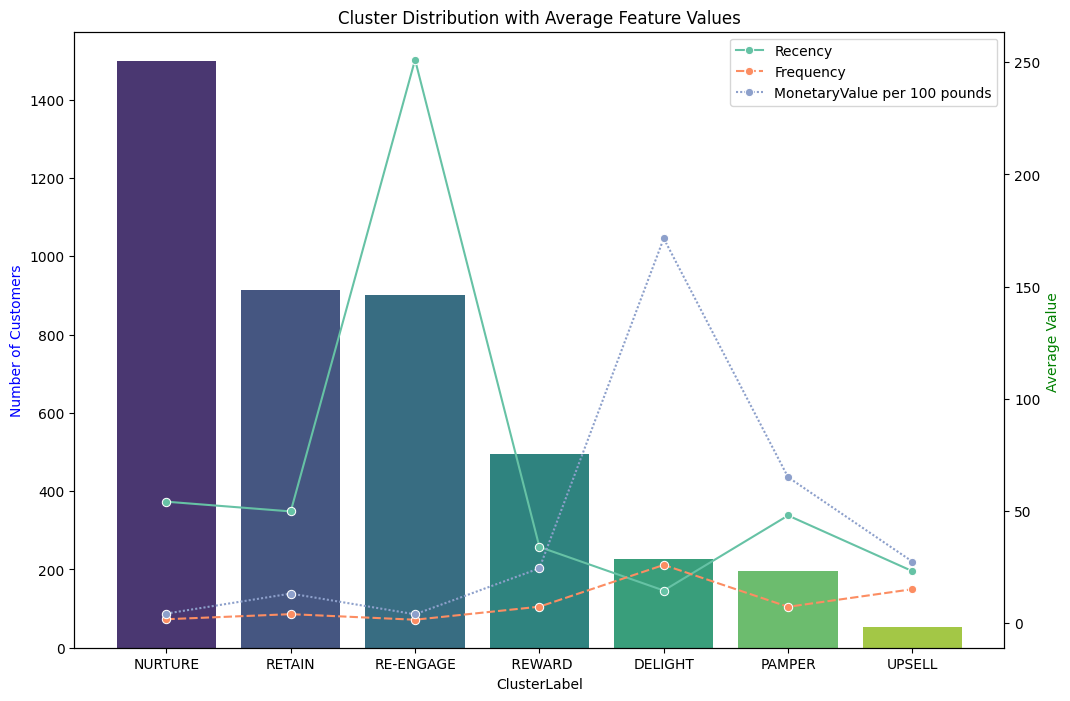

In [ ]:
cluster_counts = full_clustering_df['ClusterLabel'].value_counts() # Count the number of customers in each cluster
full_clustering_df["MonetaryValue per 100 pounds"] = full_clustering_df["MonetaryValue"]/100.00 # Create a new column for scaled monetary value
feature_means = full_clustering_df.groupby('ClusterLabel')[['Recency','Frequency',"MonetaryValue per 100 pounds"]].mean()# Compute the average Recency, Frequency, and Monetary Value per 100 pounds for each cluster

fig, ax1 =plt.subplots(figsize = (12,8)) # Create a matplotlib figure and first axis

sns.barplot(x=cluster_counts.index , y=cluster_counts.values, ax=ax1, palette ='viridis',hue = cluster_counts.index)# Plot a bar chart of the number of customers in each cluster
ax1.set_ylabel('Number of Customers',color ='b')
ax1.set_title('Cluster Distribution with Average Feature Values')

ax2 = ax1.twinx() # Create a second y-axis to plot feature averages

sns.lineplot(data = feature_means , ax=ax2 , palette ='Set2', marker = 'o') # Plot a line for each feature average (Recency, Frequency, Monetary) by cluster
ax2.set_ylabel('Average Value ', color = 'g')
plt.show() # Show the combined plot